# **Practica 3: Limpieza de Datos**

PARTICIPANTES:


*   Navarrete Tepozán Iván
*   Santos Reyes Victor Manuel
*  Gomez Cabrera Rey Ulises
*   Martinez Gutierrez Josue de Jesus



In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from scipy.stats import chi2_contingency
import os
import gdown
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import Birch,DBSCAN,KMeans,MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import NearestNeighbors

In [33]:
def grafic_barras(df, columna, ax):
    conteo = df[columna].value_counts()
    conteo.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(columna)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)

def grafic_apilada(df, columna1, columna2, ax):
    tabla = pd.crosstab(df[columna1], df[columna2])
    tabla.plot(kind='bar', stacked=True, ax=ax,
               color=['skyblue', 'mediumseagreen', 'salmon','lightcoral', 'slategray', 'khaki', 'goldenrod'],
               edgecolor='black')
    ax.set_title(f'{columna1} vs {columna2}')
    ax.tick_params(axis='x', rotation=45)

def grafic_histograma(df, columna, ax):
    sns.histplot(df[columna], kde=True, ax=ax)
    ax.set_title(f'Histograma de {columna}')
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

def grafic_boxplot(df, columna, ax):
    sns.boxplot(y=df[columna], ax=ax)
    ax.set_title(f'Boxplot de {columna}')
    ax.set_ylabel(columna)


def mostrar_graficas(df, instrucciones):
    total = len(instrucciones)
    filas = math.ceil(total / 2)
    fig, axs = plt.subplots(filas, 2, figsize=(12, 5 * filas))
    axs = axs.flatten()

    for i, instruccion in enumerate(instrucciones):
        tipo = instruccion['tipo']
        if tipo == 'barras':
            grafic_barras(df, instruccion['columna'], axs[i])
        elif tipo == 'apilada':
            grafic_apilada(df, instruccion['columna1'], instruccion['columna2'], axs[i])
        elif tipo == 'histograma':
            grafic_histograma(df, instruccion['columna'], axs[i])
        elif tipo == 'boxplot':
            grafic_boxplot(df, instruccion['columna'], axs[i])

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])


    plt.tight_layout()
    plt.show()

## **Cargamos nuestro cuestionario limpio de la practica pasada**

In [34]:
file_id = '1lOtbZAU18bU7nkJhKZCcBV2Sll1sYE7R'
file_name = 'df_SaludMental_Ver_final.xlsx'

if not os.path.exists(file_name):
    print("Descargando archivo...")
    gdown.download(f'https://drive.google.com/uc?id={file_id}', file_name, quiet=False)
else:
    print("El archivo ya está descargado.")

df_Completo = pd.read_excel('df_SaludMental_Ver_final.xlsx')
df_respaldo=pd.read_excel('df_SaludMental_Ver_final.xlsx')


Descargando archivo...


Downloading...
From: https://drive.google.com/uc?id=1lOtbZAU18bU7nkJhKZCcBV2Sll1sYE7R
To: c:\Users\xboxn\Documents\pythonPraticas\SI\NoSupervizado\df_SaludMental_Ver_final.xlsx
100%|██████████| 12.4k/12.4k [00:00<00:00, 575kB/s]


# Variables correlacionadas:

Para evaluar qué tanto influye una variable categórica en otra dentro del DataFrame, se puede usar una prueba de chi cuadrada de independencia. Esta prueba permite saber si existe una relación estadísticamente significativa entre dos variables categóricas. En este, dado la regla de decisión donde:

       p < 0.05 → Hay evidencia estadística de que las variables están relacionadas.

       p ≥ 0.05 → No hay evidencia suficiente para afirmar que están relacionadas

Asi pues, se tabulan a continuación las variables correlacionadas, siendo el estadístico Chi cuadrado un indicador de que tanto se relacionan las variables entre si.

In [35]:
resultados = []
columnas = df_Completo.columns[5:]
for i, columna1 in enumerate(columnas):
    for columna2 in columnas[i+1:]:
        tabla = pd.crosstab(df_Completo[columna1], df_Completo[columna2])
        chi2, p, dof, expected = chi2_contingency(tabla)
        if p < 0.05:
            resultados.append({
                'Variable 1': columna1,
                'Variable 2': columna2,
                'Chi2': round(chi2, 2),
                'p-valor': round(p, 4),
                'Grados de libertad': dof
            })
df_resultados = pd.DataFrame(resultados)
df_resultados.head(30)

,Variable 1,Variable 2,Chi2,p-valor,Grados de libertad
0,Sentido ansiedad/preocupación sin razón aparente,Ánimo en ultimas semanas,15.25,0.0042,4
1,Sentido ansiedad/preocupación sin razón aparente,Nivel de ánimo al despertar,13.91,0.0076,4
2,Frecuencia de Hobbies,Reacción social a terapia,15.28,0.0182,6
3,Frecuencia de Hobbies,Manejo del estrés,26.89,0.0007,8
4,Frecuencia de Hobbies,Hay Apoyo Emocional,6.55,0.0379,2
5,Frecuencia de Hobbies,Tiempo de sueño,20.08,0.0285,10
6,Frecuencia ir al especialista,Factores que afectan salud mental U,29.81,0.0126,15
7,Frecuencia ir al especialista,Manejo del estrés,22.23,0.0350,12
8,Frecuencia ir al especialista,Tiempo de sueño,37.99,0.0009,15
9,Reacción social a terapia,Manejo del estrés,22.46,0.0327,12


# **Eliminamos variables correlacionadas entre si**

In [36]:
variables_a_borrar= set()
for i, columna in df_resultados.iterrows():
        variables_a_borrar.add(columna['Variable 2'])
df_Completo.drop(columns=list(variables_a_borrar), inplace=True)

Tambien para se elimina el No de cuenta, pues para el analisis no será necesario para  el modelo, no aporta información

In [37]:
df_Completo.drop(columns=['Número de cuenta:_x'], inplace=True)

Se generan Variables  dummies

In [38]:
df_Completo=pd.get_dummies(df_Completo)
df_Completo= df_Completo.applymap(lambda x: int(x) if isinstance(x, bool) else x)

C:\Users\xboxn\AppData\Local\Temp\ipykernel_32324\2507778035.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_Completo= df_Completo.applymap(lambda x: int(x) if isinstance(x, bool) else x)


Aplicar PCA's

In [39]:
pca_pipe = make_pipeline(PCA( n_components=2), StandardScaler())
pca_pipe.fit(df_Completo)
modelo_pca = pca_pipe.named_steps['pca']
df_pca = pca_pipe.transform(df_Completo)
df_pca = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(df_pca.shape[1])])
print("Varianza explicada por los componentes:")
print(modelo_pca.explained_variance_ratio_)
print("Varianza explicada total:")
print(modelo_pca.explained_variance_ratio_.sum())

Varianza explicada por los componentes:
[0.63068551 0.0874511 ]
Varianza explicada total:
0.7181366107831534


# Nuestro df queda como:

In [40]:
df_pca.head(5)

,PC1,PC2
0,0.464751,-0.666260
1,-0.203408,0.639113
2,0.783438,1.253738
3,-0.200353,-1.003888
4,0.734141,1.156223


# Aqui inicia la parte de no supervisado

# K-MEANS

In [41]:
def silhouette(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

In [42]:
wcss = []
for i in range(2, 12):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=38482)
    kmeans.fit(df_Completo)
    wcss.append(kmeans.inertia_)

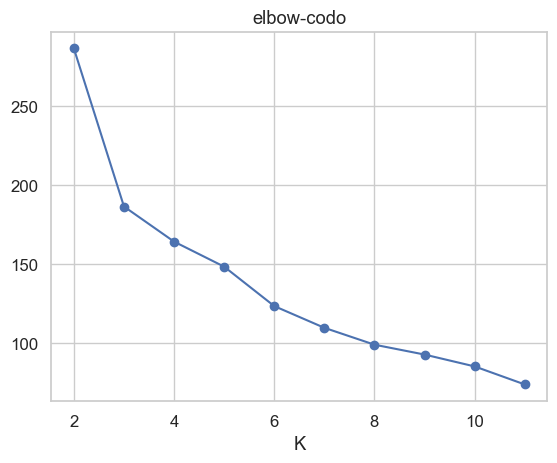

In [43]:

plt.plot(range(2, 12), wcss, marker='o')
plt.title('elbow-codo')
plt.xlabel('K')
plt.grid(True)
plt.show()



In [44]:
resultados = []
for i in range (1,100):
                seed=int(np.random.uniform(low=0,high=4294967295))
                modelo = KMeans(n_clusters=3,random_state=seed)
                etiquetas = modelo.fit_predict(df_pca)
                score = silhouette_score(df_pca, etiquetas)

                resultados.append({
                    'k': 3,
                    'seed':seed,
                    'silhouette': score
                })

df_resultados = pd.DataFrame(resultados)
mejor_config = df_resultados.sort_values(by='silhouette', ascending=False).iloc[0]
df_resultados.sort_values(by='silhouette', ascending=False).head(3)

,k,seed,silhouette
0,3,1211656689,0.513724
1,3,648841415,0.513724
2,3,552113512,0.513724


In [45]:
inits = ['k-means++', 'random']
algorithms = ['lloyd', 'elkan']
n_inits = [10, 20, 50]
resultados.clear()
clusters=[2,3,4]

for cluster in clusters:
    for init in inits:
        for algo in algorithms:
            for n_init in n_inits:
                seed=int(np.random.uniform(low=0,high=4294967295))
                modelo = KMeans(n_clusters=cluster, init=init, algorithm=algo,
                                n_init=n_init, random_state=seed)
                etiquetas = modelo.fit_predict(df_pca)
                score = silhouette_score(df_pca, etiquetas)

                resultados.append({
                    'k': cluster,
                    'init': init,
                    'algorithm': algo,
                    'n_init': n_init,
                    'seed':seed,
                    'silhouette': score
                })

df_resultados = pd.DataFrame(resultados)
mejor_config = df_resultados.sort_values(by='silhouette', ascending=False).iloc[0]
df_resultados.sort_values(by='silhouette', ascending=False).head(3)

,k,init,algorithm,n_init,seed,silhouette
31,4,random,lloyd,20,4094036942,0.518768
30,4,random,lloyd,10,2140379001,0.518768
29,4,k-means++,elkan,50,177510714,0.518768


In [46]:
km = KMeans(n_clusters=mejor_config['k'],
            init=mejor_config['init'],
            algorithm=mejor_config['algorithm'],
            n_init=mejor_config['n_init'],
            random_state=mejor_config['seed'])

y_pred = km.fit_predict(df_pca)
df_pca['Cluster_kmens'] = y_pred

score = silhouette_score(df_pca.drop(columns='Cluster_kmens'), y_pred)
print(f"Silhouette Score = {score:.4f}")


Silhouette Score = 0.5188


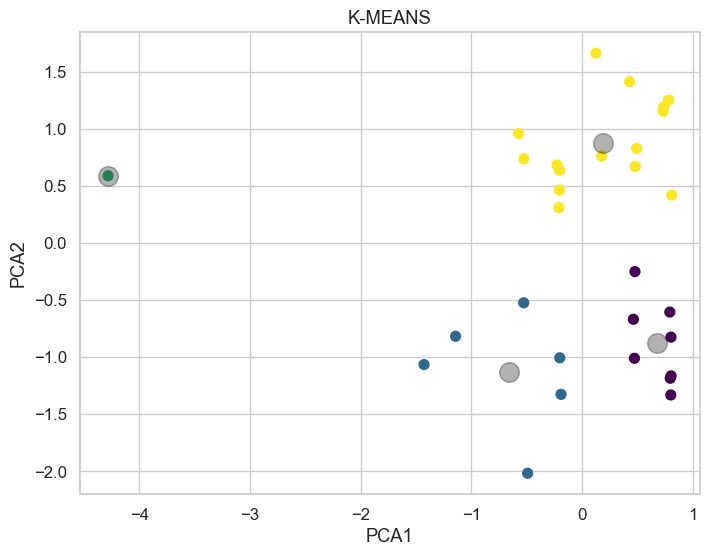

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster_kmens'], cmap='viridis', s=50)
plt.title('K-MEANS')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
centroides = km.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1], marker='o', s=200, color='black', alpha=0.3)
plt.grid(True)
plt.show()



In [48]:
df_perfilamiento = df_Completo.copy()
df_perfilamiento['Cluster']=df_pca['Cluster_kmens']
perfiles_clusters = df_perfilamiento.groupby('Cluster').mean()
perfiles_clusters.to_excel('Perfiles_kmeans_Clusters.xlsx')

In [49]:
df_respaldo=df_respaldo.join(df_pca['Cluster_kmens'])
df_respaldo.head(30)
df_respaldo.to_excel('df_SaludMentalConClusters.xlsx')
df_pca.drop(columns='Cluster_kmens', inplace=True)

In [50]:
perfiles_clusters.head()

,Generación,Frecuencia de estrés,Hablar con alguien cuando te sientes mal,Sentido ansiedad/preocupación sin razón aparente,Frecuencia de Hobbies,Frecuencia ir al especialista,Nivel Comodidad con especialista,Reaccion si cuentas tus sentmientos,Ingresó en:_Preparatoria,Ingresó en:_Universidad,Temor sobre la terapia_Enfrentar la verdad,Temor sobre la terapia_Ninguna,Temor sobre la terapia_No funcione,Definición Bienestar_Equilibrio,Definición Bienestar_Felicidad,Definición Bienestar_Otro,Definición Bienestar_Paz,Definición Bienestar_Salud,Preferencia Edad Psicólogo_Indiferente,Preferencia Edad Psicólogo_Joven,Preferencia Edad Psicólogo_Mayor,Quienes van al psicologo_otros,Quienes van al psicologo_quien tiene problemas,Quienes van al psicologo_todos
Cluster,,,,,,,,,,,,,,,,,,,,,,,,
0,2022.625,1.375,0.625,0.000000,1.750000,2.625000,2.500000,1.000000,0.0,1.0,0.000000,0.375000,0.625000,0.000000,0.625000,0.125,0.125000,0.125000,0.375000,0.375000,0.250000,0.375000,0.125000,0.500000
1,2018.500,1.500,1.000,0.000000,2.500000,3.000000,2.666667,1.000000,1.0,0.0,0.166667,0.166667,0.666667,0.000000,0.833333,0.000,0.166667,0.000000,0.333333,0.666667,0.000000,0.166667,0.166667,0.666667
2,2007.000,2.000,0.000,2.000000,1.000000,3.000000,1.000000,1.000000,1.0,0.0,0.000000,1.000000,0.000000,0.000000,1.000000,0.000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
3,2021.200,2.400,0.800,1.933333,2.133333,2.733333,2.333333,0.933333,0.4,0.6,0.333333,0.133333,0.533333,0.266667,0.333333,0.000,0.333333,0.066667,0.133333,0.600000,0.266667,0.200000,0.333333,0.466667


#DBSCAN


--- Ejecutando Búsqueda de 'eps' para DBSCAN ---


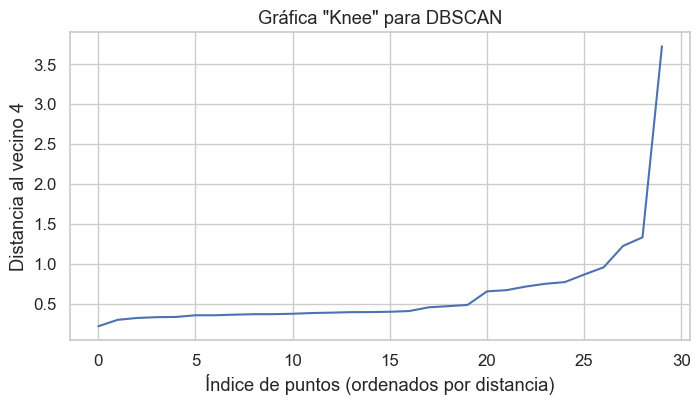

Clusters encontrados por DBSCAN: [-1  0]
El cluster -1 representa los outliers (ruido).
Número de clusters reales encontrados (sin outliers): 1
No se puede calcular el Coeficiente de Silueta (se necesita > 1 cluster real).

--- 4. Perfil de Clusters (Medias) ---
Mostrando perfil de clusters (incluyendo ruido como cluster -1):
cluster                                                    -1            0
Generación                                        2013.333333  2021.370370
Frecuencia de estrés                                 1.666667     1.962963
Hablar con alguien cuando te sientes mal             0.666667     0.777778
Sentido ansiedad/preocupación sin razón aparente     0.666667     1.074074
Frecuencia de Hobbies                                2.000000     2.074074
Frecuencia ir al especialista                        3.000000     2.740741
Nivel Comodidad con especialista                     1.666667     2.481481
Reaccion si cuentas tus sentmientos                  1.000000     0.9629

C:\Users\xboxn\AppData\Local\Temp\ipykernel_32324\982815466.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels) + 1)


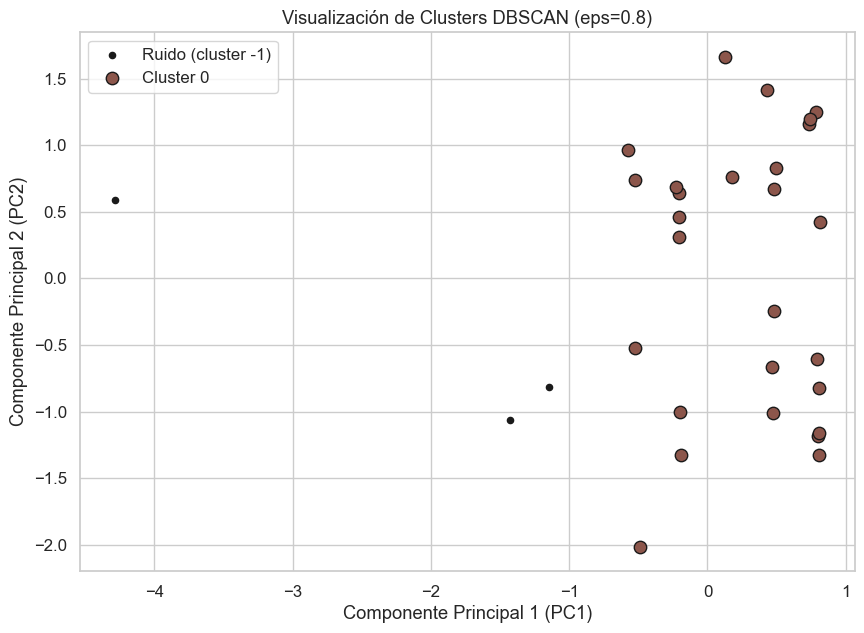

In [51]:
print("\n--- Ejecutando Búsqueda de 'eps' para DBSCAN ---")

min_samples_dbscan = 4


neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors_fit = neighbors.fit(df_pca)
distances, indices = neighbors_fit.kneighbors(df_pca)

# Graficamos las distancias
distances_sorted = np.sort(distances[:, min_samples_dbscan-1], axis=0)
plt.figure(figsize=(8, 4))
plt.plot(distances_sorted)
plt.title('Gráfica "Knee" para DBSCAN')
plt.xlabel('Índice de puntos (ordenados por distancia)')
plt.ylabel(f'Distancia al vecino {min_samples_dbscan}')
plt.grid(True)
plt.show()


eps_optimo = 0.8

# Modelo DBSCAN
dbscan_model = DBSCAN(eps=eps_optimo, min_samples=min_samples_dbscan)
dbscan_labels = dbscan_model.fit_predict(df_pca)

print(f"Clusters encontrados por DBSCAN: {np.unique(dbscan_labels)}")
if -1 in np.unique(dbscan_labels):
    print("El cluster -1 representa los outliers (ruido).")


core_samples_mask = dbscan_labels != -1

core_labels = dbscan_labels[core_samples_mask]

# Clusters unicos
n_clusters_found = len(np.unique(core_labels))

print(f"Número de clusters reales encontrados (sin outliers): {n_clusters_found}")


if n_clusters_found > 1:
    print(f"Coeficiente de Silueta (sin outliers): {silhouette_score(df_pca[core_samples_mask], core_labels)}")
else:
    print("No se puede calcular el Coeficiente de Silueta (se necesita > 1 cluster real).")


# --- Perfilamiento de los Clusters de DBSCAN ---
print("\n--- 4. Perfil de Clusters (Medias) ---")


df_Completo['cluster'] = dbscan_labels


cluster_profile = df_Completo.groupby('cluster').mean()

print("Mostrando perfil de clusters (incluyendo ruido como cluster -1):")
print(cluster_profile.T)


cluster_profile.T.to_excel("perfil_de_clusters_DBSCAN.xlsx")

print("\nAnálisis de perfiles de DBSCAN guardado en 'perfil_de_clusters_DBSCAN.xlsx'")

# --- Visualización de Resultados ---

print("\n--- Generando gráfica de clusters ---")

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7))
ax = plt.subplot(111)


unique_labels = np.unique(dbscan_labels)


colors = plt.cm.get_cmap('tab10', len(unique_labels) + 1)


for i, k in enumerate(unique_labels):

    class_mask = (dbscan_labels == k)

    subset = df_pca.loc[class_mask]


    if k == -1:

        ax.scatter(subset['PC1'], subset['PC2'],
                   s=20, color='k',
                   label='Ruido (cluster -1)')
    else:

        ax.scatter(subset['PC1'], subset['PC2'],
                   s=80, color=colors(i),
                   label=f'Cluster {k}',
                   edgecolors='k')


ax.legend(loc='best')
plt.title(f'Visualización de Clusters DBSCAN (eps={eps_optimo})')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.grid(True)
plt.show()

In [52]:
cluster_profile.head()

,Generación,Frecuencia de estrés,Hablar con alguien cuando te sientes mal,Sentido ansiedad/preocupación sin razón aparente,Frecuencia de Hobbies,Frecuencia ir al especialista,Nivel Comodidad con especialista,Reaccion si cuentas tus sentmientos,Ingresó en:_Preparatoria,Ingresó en:_Universidad,Temor sobre la terapia_Enfrentar la verdad,Temor sobre la terapia_Ninguna,Temor sobre la terapia_No funcione,Definición Bienestar_Equilibrio,Definición Bienestar_Felicidad,Definición Bienestar_Otro,Definición Bienestar_Paz,Definición Bienestar_Salud,Preferencia Edad Psicólogo_Indiferente,Preferencia Edad Psicólogo_Joven,Preferencia Edad Psicólogo_Mayor,Quienes van al psicologo_otros,Quienes van al psicologo_quien tiene problemas,Quienes van al psicologo_todos
cluster,,,,,,,,,,,,,,,,,,,,,,,,
-1,2013.333333,1.666667,0.666667,0.666667,2.000000,3.000000,1.666667,1.000000,1.00000,0.00000,0.333333,0.333333,0.333333,0.000000,0.666667,0.000000,0.333333,0.000000,0.333333,0.666667,0.000000,0.333333,0.000000,0.666667
0,2021.370370,1.962963,0.777778,1.074074,2.074074,2.740741,2.481481,0.962963,0.37037,0.62963,0.185185,0.222222,0.592593,0.148148,0.518519,0.037037,0.222222,0.074074,0.222222,0.555556,0.222222,0.222222,0.259259,0.518519


# BIRCH con global clustering y sin global (usando RandomizedSearchCV)

C:\Users\xboxn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



*** Mejores parámetros encontrados ***
{'threshold': np.float64(0.2), 'n_clusters': 8, 'branching_factor': 10}

**** BIRCH sin global clustering *****
Hiperparámetros usados: threshold=0.2, branching_factor=10, n_clusters=8
Clústeres generados: 8
Silhouette score: 0.4567

**** BIRCH con global clustering *****
Hiperparámetros usados: threshold=1.0, branching_factor=10, n_clusters=4
Clústeres generados: 4
Silhouette score: 0.5188


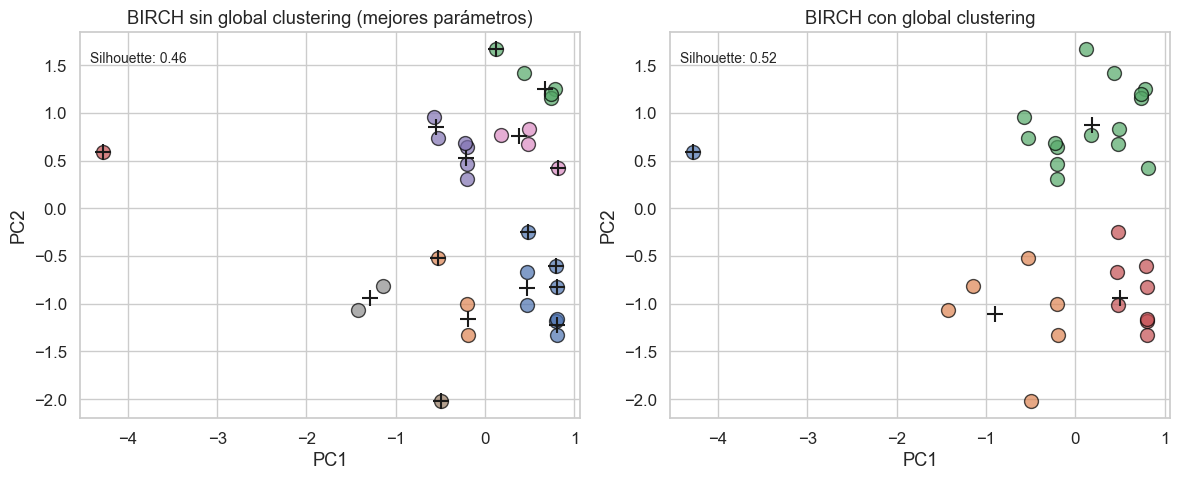

In [53]:

# Usar todas las columnas de df_pca para entrenar
X = df_pca.values  # todas las PCs


# funcion de scoring personalizada
def silhouette_scorer(estimator, X):
  labels = estimator.fit_predict(X)
  if len(np.unique(labels)) > 1:
    return silhouette_score(X, labels)
  else:
    return -1  # Penalizar modelos con un solo clúster


# Búsqueda de hiperparámetros
birch_base = Birch()

param_distributions = {
  'threshold': np.linspace(0.1, 1.0, 10),
  'branching_factor': [5, 10, 20],
  'n_clusters': [None, 2, 3, 4, 5, 6, 8]
}

random_search = RandomizedSearchCV(
  estimator=birch_base,
  param_distributions=param_distributions,
  n_iter=15,
  scoring=make_scorer(silhouette_scorer),
  cv=None,
  random_state=50,
  n_jobs=-1
)

# Busqueda
random_search.fit(X)

best_params = random_search.best_params_

print("\n*** Mejores parámetros encontrados ***")
print(best_params)


#########################################
# BIRCH sin global clustering
birch_no_global = Birch(
  threshold=best_params['threshold'],
  branching_factor=best_params['branching_factor'],
  n_clusters=best_params['n_clusters']
)
birch_no_global.fit(X)

labels_no_global = birch_no_global.labels_
centroids_no_global = birch_no_global.subcluster_centers_

if len(np.unique(labels_no_global)) > 1:
  sil_no_global = silhouette_score(X, labels_no_global)
else:
  sil_no_global = np.nan

print("\n**** BIRCH sin global clustering *****")
print(f"Hiperparámetros usados: threshold={best_params['threshold']}, "
      f"branching_factor={best_params['branching_factor']}, "
      f"n_clusters={best_params['n_clusters']}")
print(f"Clústeres generados: {len(np.unique(labels_no_global))}")
print(f"Silhouette score: {sil_no_global:.4f}")

################################
# BIRCH con global clustering
# El agrupador global de scikit-learn, por defecto, es K-Means
birch_global = Birch(threshold=0.7, branching_factor=10, n_clusters=4)
birch_global.fit(X)

labels_global = birch_global.labels_
centroids_global = birch_global.subcluster_centers_

sil_global = silhouette_score(X, labels_global)

print("\n**** BIRCH con global clustering *****")
print(f"Hiperparámetros usados: threshold=1.0, branching_factor=10, n_clusters=4")
print(f"Clústeres generados: {len(np.unique(labels_global))}")
print(f"Silhouette score: {sil_global:.4f}")

##

X_2d = X
centroids_no_global_2d = centroids_no_global[:, :2]
centroids_global_2d = centroids_global[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sin clustering global
ax = axes[0]
for i in np.unique(labels_no_global):
  mask = labels_no_global == i
  ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=100, edgecolor='black', alpha=0.7)
ax.scatter(centroids_no_global_2d[:, 0], centroids_no_global_2d[:, 1],
           c='k', marker='+', s=120)
ax.set_title("BIRCH sin global clustering (mejores parámetros)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.text(0.02, 0.95, f"Silhouette: {sil_no_global:.2f}",
        transform=ax.transAxes, fontsize=10, verticalalignment='top')

# Con clustering global
ax = axes[1]
for i in np.unique(labels_global):
  mask = labels_global == i
  ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=100, edgecolor='black', alpha=0.7)
ax.scatter(centroids_global_2d[:, 0], centroids_global_2d[:, 1],
           c='k', marker='+', s=120)
ax.set_title("BIRCH con global clustering")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.text(0.02, 0.95, f"Silhouette: {sil_global:.2f}",
        transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()


In [54]:
df_perfilamiento = df_Completo.copy()

df_perfilamiento.drop(columns=['cluster'], inplace=True)

df_perfilamiento['Cluster'] = labels_global

perfiles_clusters = df_perfilamiento.groupby('Cluster').mean()

perfiles_clusters.to_excel('Perfiles_Birch_Clusters.xlsx')

In [55]:
perfiles_clusters.head()

,Generación,Frecuencia de estrés,Hablar con alguien cuando te sientes mal,Sentido ansiedad/preocupación sin razón aparente,Frecuencia de Hobbies,Frecuencia ir al especialista,Nivel Comodidad con especialista,Reaccion si cuentas tus sentmientos,Ingresó en:_Preparatoria,Ingresó en:_Universidad,Temor sobre la terapia_Enfrentar la verdad,Temor sobre la terapia_Ninguna,Temor sobre la terapia_No funcione,Definición Bienestar_Equilibrio,Definición Bienestar_Felicidad,Definición Bienestar_Otro,Definición Bienestar_Paz,Definición Bienestar_Salud,Preferencia Edad Psicólogo_Indiferente,Preferencia Edad Psicólogo_Joven,Preferencia Edad Psicólogo_Mayor,Quienes van al psicologo_otros,Quienes van al psicologo_quien tiene problemas,Quienes van al psicologo_todos
Cluster,,,,,,,,,,,,,,,,,,,,,,,,
0,2007.000,2.000,0.000,2.000000,1.000000,3.000000,1.000000,1.000000,1.0,0.0,0.000000,1.000000,0.000000,0.000000,1.000000,0.000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
1,2018.500,1.500,1.000,0.000000,2.500000,3.000000,2.666667,1.000000,1.0,0.0,0.166667,0.166667,0.666667,0.000000,0.833333,0.000,0.166667,0.000000,0.333333,0.666667,0.000000,0.166667,0.166667,0.666667
2,2021.200,2.400,0.800,1.933333,2.133333,2.733333,2.333333,0.933333,0.4,0.6,0.333333,0.133333,0.533333,0.266667,0.333333,0.000,0.333333,0.066667,0.133333,0.600000,0.266667,0.200000,0.333333,0.466667
3,2022.625,1.375,0.625,0.000000,1.750000,2.625000,2.500000,1.000000,0.0,1.0,0.000000,0.375000,0.625000,0.000000,0.625000,0.125,0.125000,0.125000,0.375000,0.375000,0.250000,0.375000,0.125000,0.500000


<Figure size 1200x600 with 0 Axes>

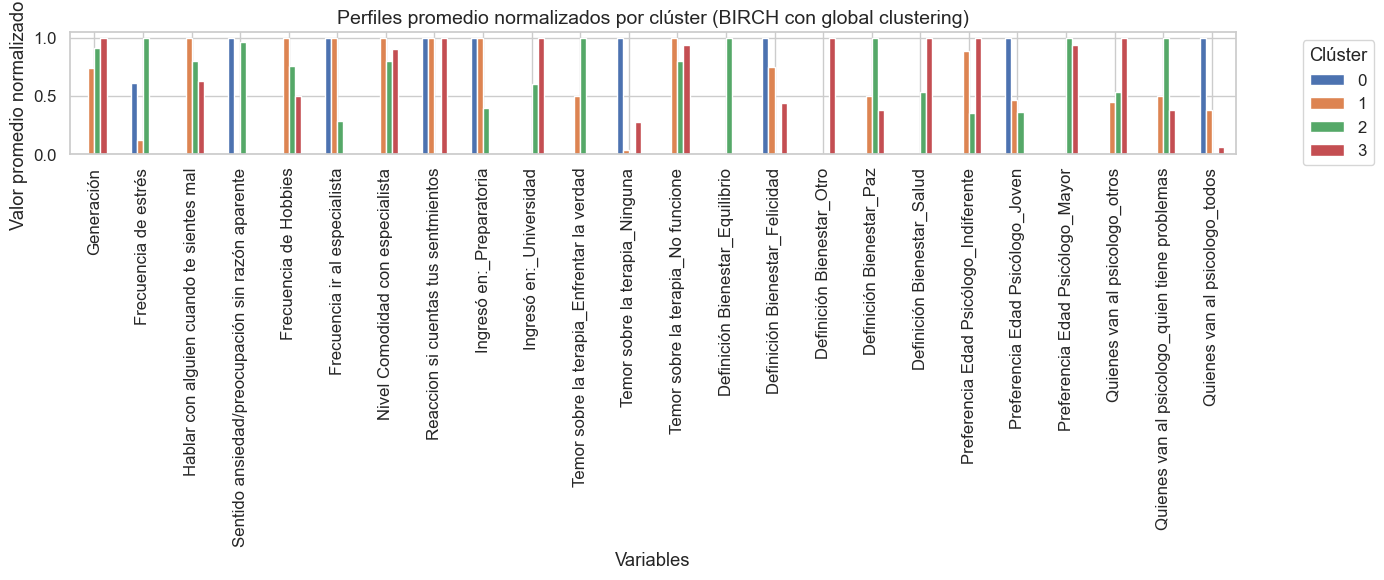

In [56]:
sns.set(style="whitegrid", font_scale=1.1)

perfiles_norm = (perfiles_clusters - perfiles_clusters.min()) / (perfiles_clusters.max() - perfiles_clusters.min())

# Crear figura
plt.figure(figsize=(12, 6))
perfiles_norm.T.plot(kind='bar', figsize=(14, 6))

plt.title("Perfiles promedio normalizados por clúster (BIRCH con global clustering)", fontsize=14)
plt.xlabel("Variables")
plt.ylabel("Valor promedio normalizado (0-1)")
plt.legend(title="Clúster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Mean Shift

clusters: 4


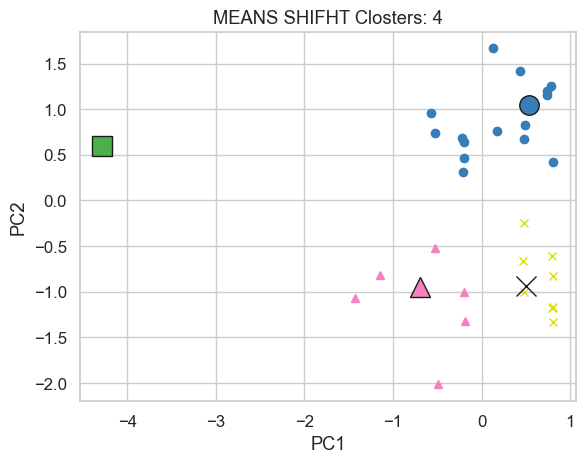

In [57]:

X = df_pca.values

bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=500)

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

print("clusters: %d" % n_clusters_)

plt.figure(1)
plt.clf()

colors = ["#dede00", "#377eb8", "#f781bf", "#4daf4a", "#984ea3", "#ff7f00"]
markers = ["x", "o", "^", "s", "P", "D"]
for k in range(n_clusters_):
    col = colors[k % len(colors)]
    marker = markers[k % len(markers)]
    my_members = labels == k
    cluster_center = cluster_centers[k]
    plt.plot(X[my_members, 0], X[my_members, 1], marker, color=col)
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        marker,
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=14,
    )

plt.title("MEANS SHIFHT Closters: %d" % n_clusters_)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


In [58]:
df_perfilamiento = df_Completo.copy()
df_perfilamiento['Cluster']=labels
perfiles_clusters = df_perfilamiento.groupby('Cluster').mean()
perfiles_clusters.to_excel('Perfiles_MeanShift_Clusters.xlsx')

# Perfilamineto

In [59]:
perfiles_clusters.head()

,Generación,Frecuencia de estrés,Hablar con alguien cuando te sientes mal,Sentido ansiedad/preocupación sin razón aparente,Frecuencia de Hobbies,Frecuencia ir al especialista,Nivel Comodidad con especialista,Reaccion si cuentas tus sentmientos,Ingresó en:_Preparatoria,Ingresó en:_Universidad,Temor sobre la terapia_Enfrentar la verdad,Temor sobre la terapia_Ninguna,Temor sobre la terapia_No funcione,Definición Bienestar_Equilibrio,Definición Bienestar_Felicidad,Definición Bienestar_Otro,Definición Bienestar_Paz,Definición Bienestar_Salud,Preferencia Edad Psicólogo_Indiferente,Preferencia Edad Psicólogo_Joven,Preferencia Edad Psicólogo_Mayor,Quienes van al psicologo_otros,Quienes van al psicologo_quien tiene problemas,Quienes van al psicologo_todos,cluster
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,
0,2022.625,1.375,0.625,0.000000,1.750000,2.625000,2.500000,1.000000,0.0,1.0,0.000000,0.375000,0.625000,0.000000,0.625000,0.125,0.125000,0.125000,0.375000,0.375000,0.250000,0.375000,0.125000,0.500000,0.000000
1,2021.200,2.400,0.800,1.933333,2.133333,2.733333,2.333333,0.933333,0.4,0.6,0.333333,0.133333,0.533333,0.266667,0.333333,0.000,0.333333,0.066667,0.133333,0.600000,0.266667,0.200000,0.333333,0.466667,0.000000
2,2018.500,1.500,1.000,0.000000,2.500000,3.000000,2.666667,1.000000,1.0,0.0,0.166667,0.166667,0.666667,0.000000,0.833333,0.000,0.166667,0.000000,0.333333,0.666667,0.000000,0.166667,0.166667,0.666667,-0.333333
3,2007.000,2.000,0.000,2.000000,1.000000,3.000000,1.000000,1.000000,1.0,0.0,0.000000,1.000000,0.000000,0.000000,1.000000,0.000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,-1.000000


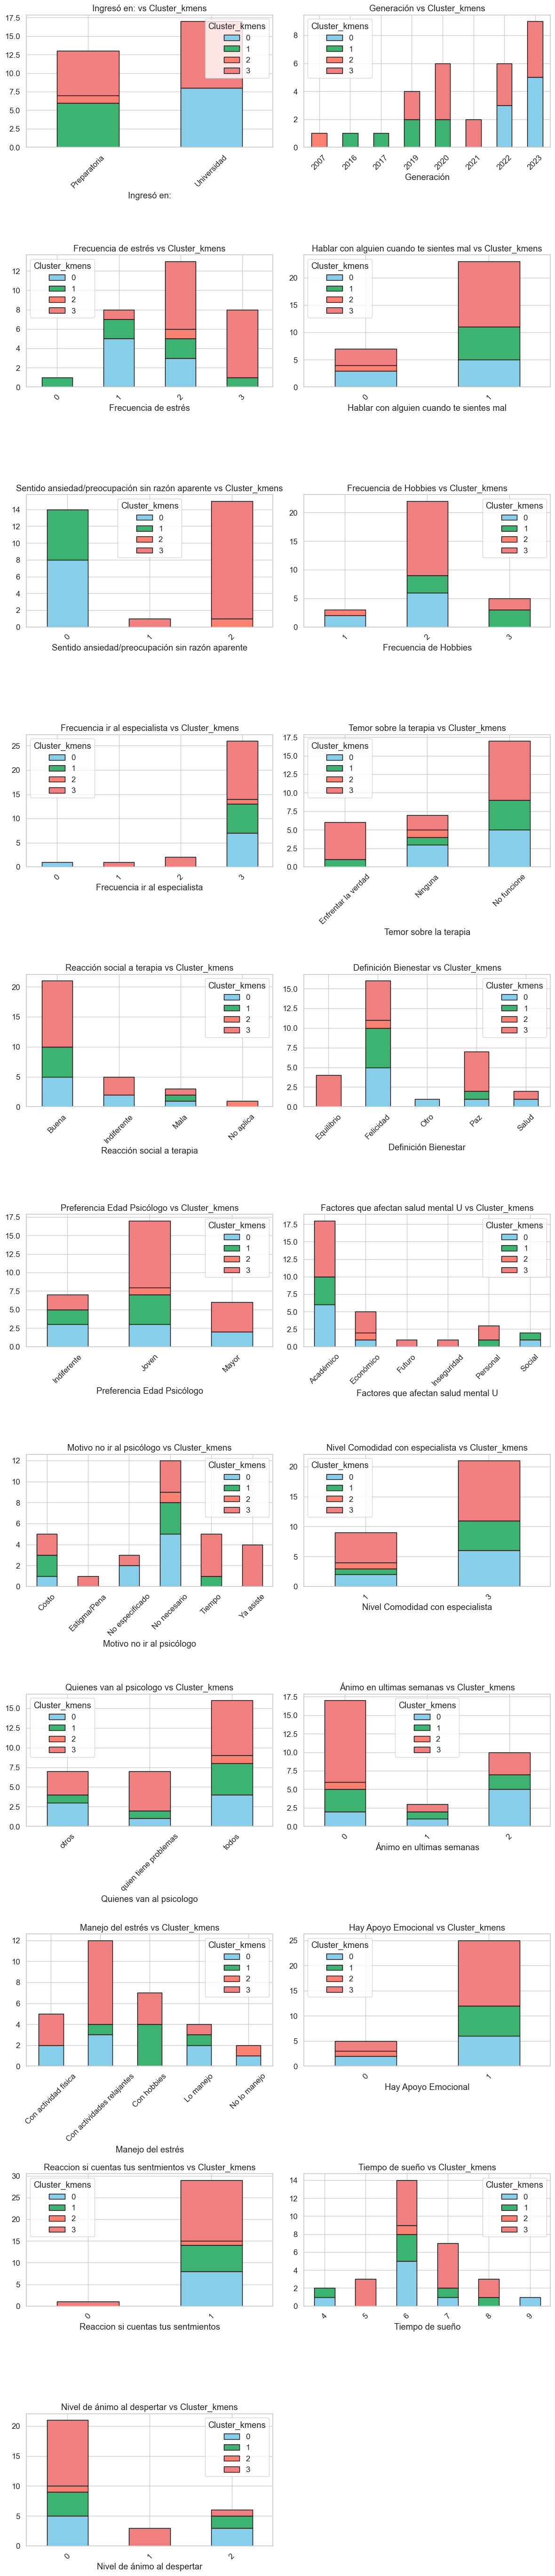

In [60]:
instrucciones = []

for col in df_respaldo.columns.to_list():
    if col not in  ['Cluster_kmens','Número de cuenta:_x']:
        instrucciones.append({'tipo': 'apilada', 'columna2': 'Cluster_kmens', 'columna1': col})

mostrar_graficas(df_respaldo, instrucciones)